In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# delete (...)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) 
df = pd.read_csv('group_26_train.csv')
df['f2'] = pd.to_datetime(df['f2'], format='mixed', errors='coerce')

df['hour'] = df['f2'].dt.hour
df['dayofweek'] = df['f2'].dt.dayofweek
df['month'] = df['f2'].dt.month
df['year'] = df['f2'].dt.year

df['dayofweek'] = df['dayofweek'].astype('str')
df['month'] = df['month'].astype('str')


display(df[['f2', 'year', 'month', 'dayofweek', 'hour']].head())

df = df.drop(columns=['f2'])

day_night_cols = ['f31','f32', 'f33', 'f34']

for col in day_night_cols:
    df[col] = df[col].map({'Day': False, 'Night': True}).astype(bool)
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)

,f2,year,month,dayofweek,hour
0,2018-03-30 17:32:46,2018,3,4,17
1,2022-07-27 13:42:00,2022,7,2,13
2,2022-06-06 13:00:30,2022,6,0,13
3,2021-09-07 21:50:00,2021,9,1,21
4,2019-05-23 20:52:35,2019,5,3,20


Numeric columns: 13
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20', 'hour', 'year']

Categorical columns: 11
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


Pearson and Spearman Correlation Heatmap between Numerical Features

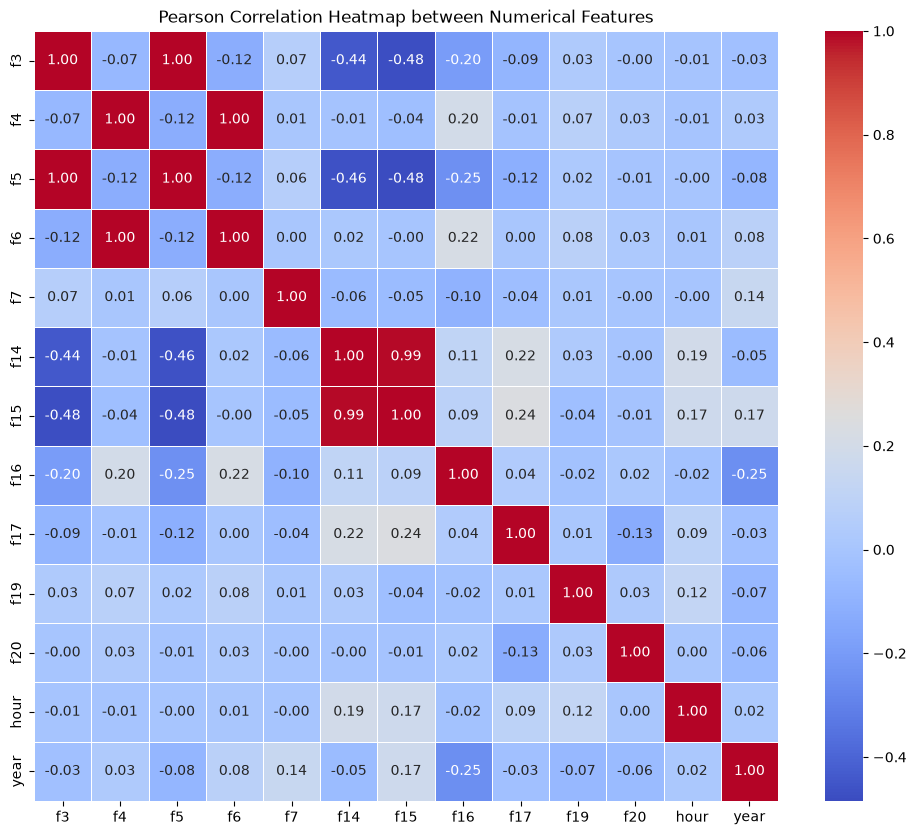

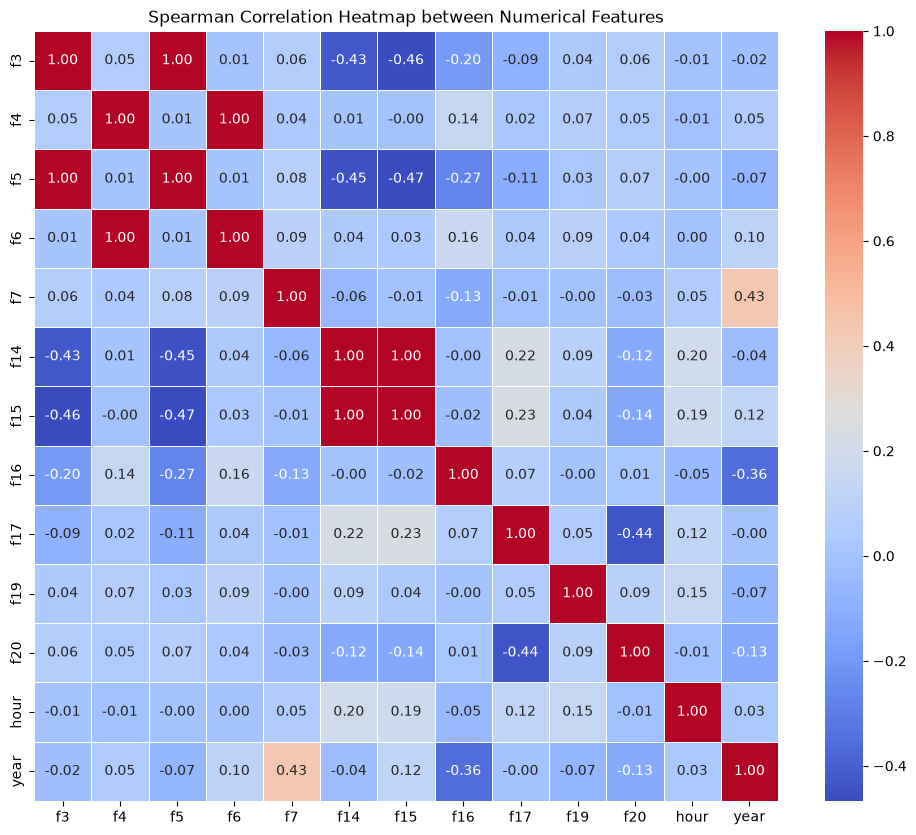

In [12]:
if numeric_cols:
    # Pearson Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Heatmap between Numerical Features')
    plt.show()

    # Spearman Correl ation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Spearman Correlation Heatmap between Numerical Features')
    plt.show()
else:
    print("No numerical columns found for correlation analysis.")


Cramer's V Heatmap between Categorical Features

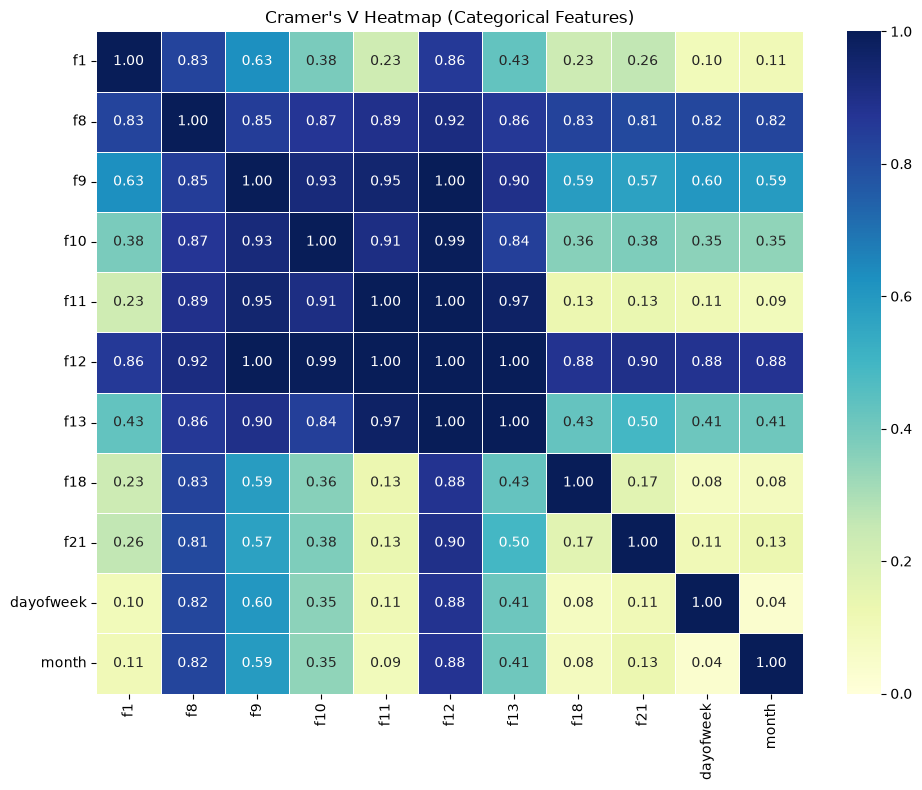

In [13]:
def cramers_v(x, y):

    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.empty or confusion_matrix.to_numpy().sum() == 0:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape

    if min(r - 1, k - 1) <= 0:
        return 0.0

    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

cat_cols = [
    c
    for c in sample_df.select_dtypes(
        include=['object', 'category']
    ).columns
    if c != 'f2'
]


cramers_matrix = pd.DataFrame(
    np.eye(len(cat_cols)),
    index=cat_cols,
    columns=cat_cols
)


for i, col1 in enumerate(cat_cols):

    for j, col2 in enumerate(cat_cols):

        if i < j:

            val = cramers_v(
                sample_df[col1],
                sample_df[col2]
            )

            cramers_matrix.loc[col1, col2] = val
            cramers_matrix.loc[col2, col1] = val


plt.figure(figsize=(10, 8))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='YlGnBu',
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=.5
)

plt.title("Cramer's V Heatmap (Categorical Features)")
plt.tight_layout()
plt.show()

Chi-Square P-value Heatmap between Categorical Features

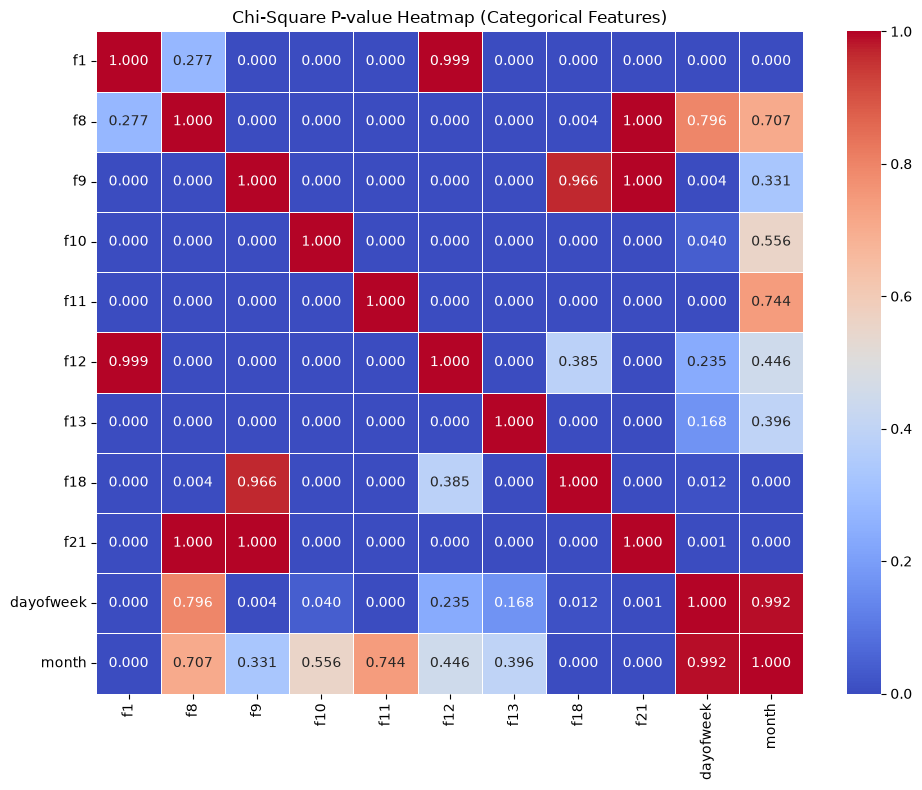

In [14]:
def chi_pvalue(x, y):

    confusion_matrix = pd.crosstab(x, y)

    if confusion_matrix.empty or confusion_matrix.to_numpy().sum() == 0:
        return np.nan

    try:
        _, p, _, _ = chi2_contingency(confusion_matrix)
        return p

    except:
        return np.nan


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

cat_cols = [
    c
    for c in sample_df.select_dtypes(
        include=['object', 'category']
    ).columns
    if c != 'f2'
]


chi_matrix = pd.DataFrame(
    np.eye(len(cat_cols)),
    index=cat_cols,
    columns=cat_cols
)


for i, col1 in enumerate(cat_cols):

    for j, col2 in enumerate(cat_cols):

        if i < j:

            val = chi_pvalue(
                sample_df[col1],
                sample_df[col2]
            )

            chi_matrix.loc[col1, col2] = val
            chi_matrix.loc[col2, col1] = val


plt.figure(figsize=(10, 8))

sns.heatmap(
    chi_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    fmt=".3f",
    linewidths=.5
)

plt.title("Chi-Square P-value Heatmap (Categorical Features)")
plt.tight_layout()
plt.show()

Chi-Square p-values Heatmap between Boolean Features

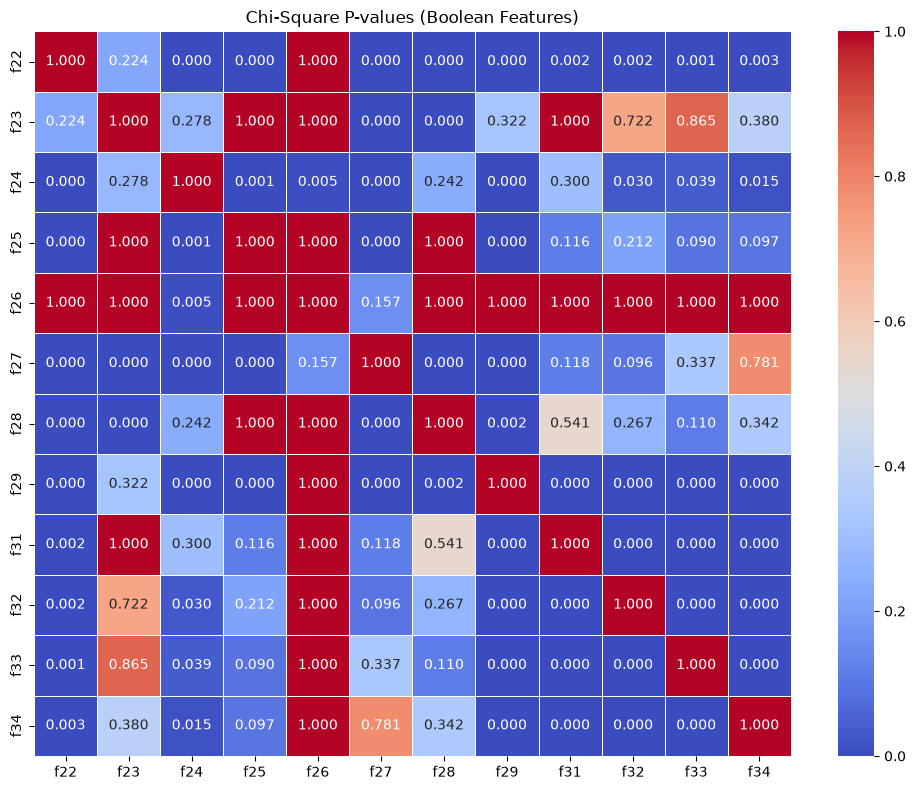

In [15]:
if 'bool_cols' in locals() and len(bool_cols) >= 2:

    valid_bool_cols = [
        c
        for c in bool_cols
        if c in df.columns and df[c].nunique(dropna=True) > 1
    ]

    if len(valid_bool_cols) >= 2:

        pval_matrix = pd.DataFrame(
            1.0,
            index=valid_bool_cols,
            columns=valid_bool_cols
        )

        for i, col1 in enumerate(valid_bool_cols):

            for col2 in valid_bool_cols[i + 1:]:

                table = pd.crosstab(df[col1], df[col2])

                if table.shape[0] > 1 and table.shape[1] > 1:

                    _, p_val, _, _ = chi2_contingency(table)

                    pval_matrix.loc[col1, col2] = p_val
                    pval_matrix.loc[col2, col1] = p_val


        plt.figure(figsize=(10, 8))

        sns.heatmap(
            pval_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=0,
            vmax=1,
            fmt=".3f",
            linewidths=.5
        )

        plt.title('Chi-Square P-values (Boolean Features)')
        plt.tight_layout()
        plt.show()

Cramer's V Heatmap between Boolean Features

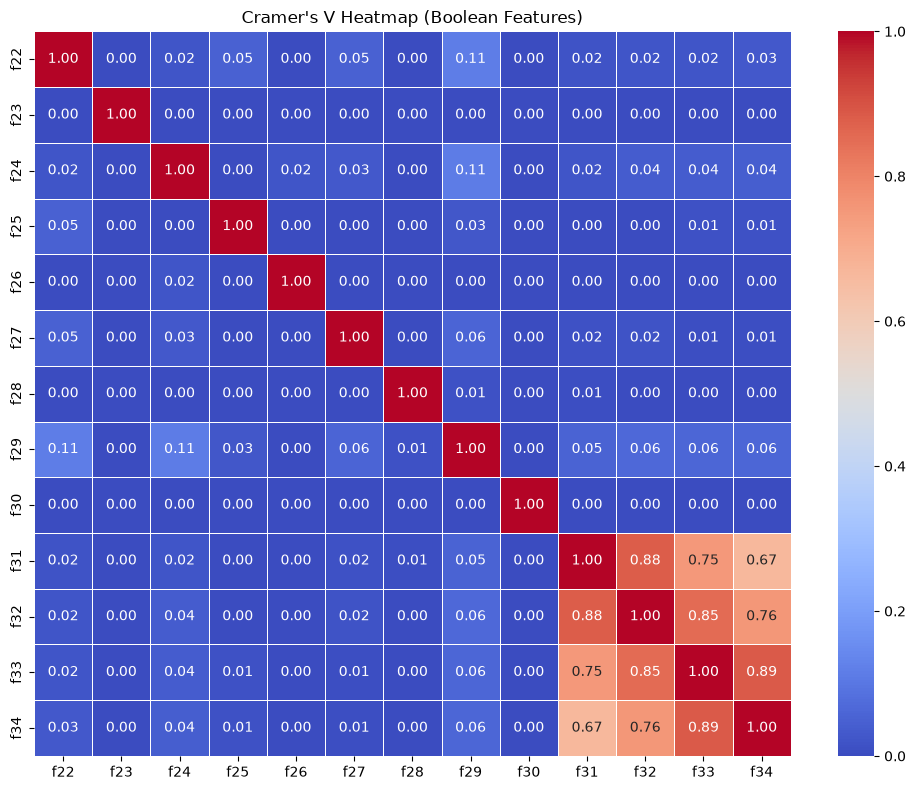

In [16]:
def cramers_v(x, y):

    tbl = pd.crosstab(x, y)

    if tbl.empty:
        return np.nan

    try:

        chi2 = chi2_contingency(tbl)[0]

        n = tbl.to_numpy().sum()

        r, k = tbl.shape

        if min(r - 1, k - 1) <= 0:
            return 0

        return np.sqrt(
            (chi2 / n) /
            min(r - 1, k - 1)
        )

    except:

        return np.nan


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)

bool_cols = [
    c
    for c in sample_df.select_dtypes(
        include=["bool"]
    ).columns
    if c != "f2"
]


bool_matrix = pd.DataFrame(
    np.eye(len(bool_cols)),
    index=bool_cols,
    columns=bool_cols
)


for i, c1 in enumerate(bool_cols):

    for j, c2 in enumerate(bool_cols):

        if i < j:

            val = cramers_v(
                sample_df[c1],
                sample_df[c2]
            )

            bool_matrix.loc[c1, c2] = val
            bool_matrix.loc[c2, c1] = val


plt.figure(figsize=(10, 8))

sns.heatmap(
    bool_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=.5
)

plt.title("Cramer's V Heatmap (Boolean Features)")
plt.tight_layout()
plt.show()

Chi-Square P-value Heatmap (Categorical vs Boolean)

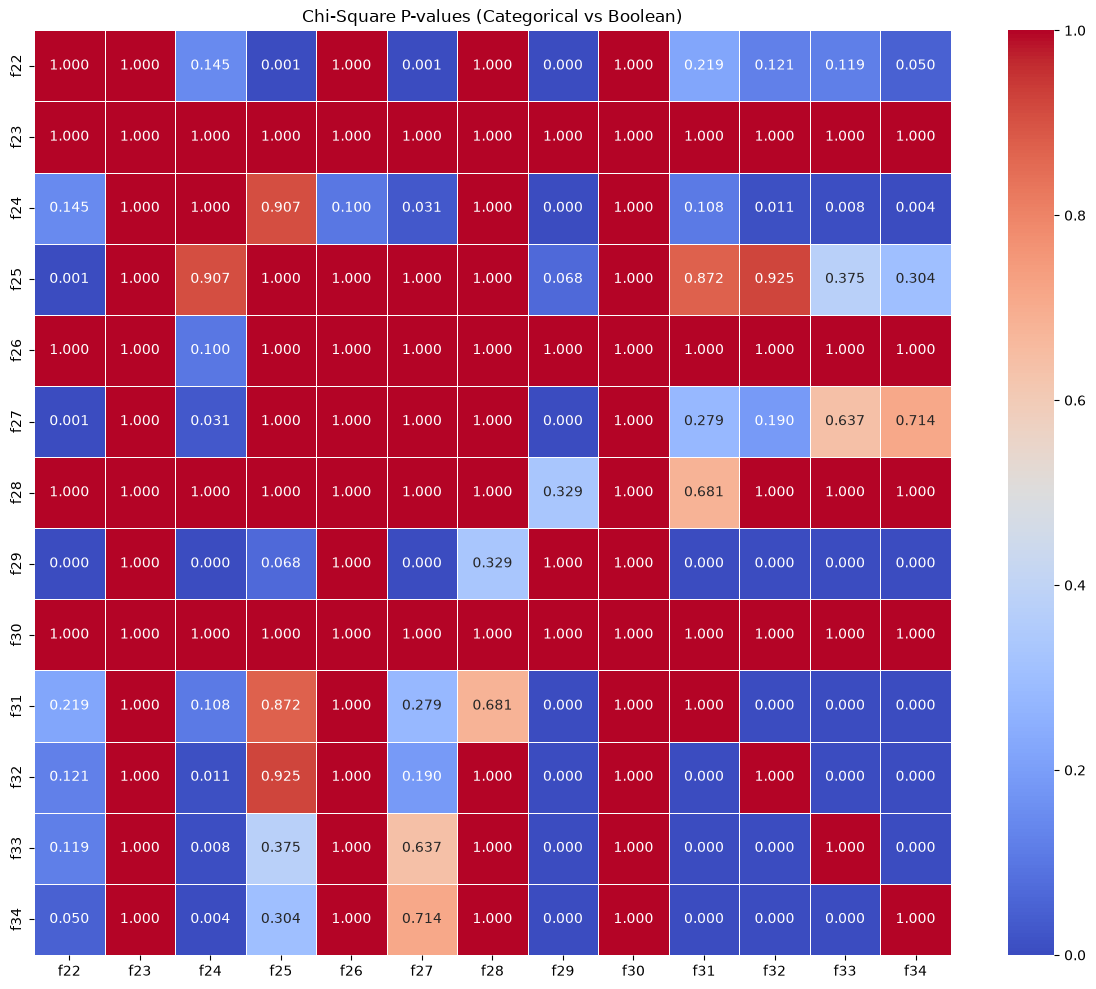

In [17]:
def chi_pvalue(x, y):

    tbl = pd.crosstab(x, y)

    if tbl.empty or tbl.to_numpy().sum() == 0:
        return np.nan

    try:
        _, p, _, _ = chi2_contingency(tbl)
        return p

    except:
        return np.nan


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)


cat_bool_cols = [
    c
    for c in sample_df.columns
    if (
        sample_df[c].dtype == "object"
        or str(sample_df[c].dtype) == "category"
        or sample_df[c].dtype == "bool"
    )
]

if "f2" in cat_bool_cols:
    cat_bool_cols.remove("f2")


chi_matrix = pd.DataFrame(
    np.eye(len(cat_bool_cols)),
    index=cat_bool_cols,
    columns=cat_bool_cols
)


for i, col1 in enumerate(cat_bool_cols):

    for j, col2 in enumerate(cat_bool_cols):

        if i < j:

            val = chi_pvalue(
                sample_df[col1],
                sample_df[col2]
            )

            chi_matrix.loc[col1, col2] = val
            chi_matrix.loc[col2, col1] = val


plt.figure(figsize=(12, 10))

sns.heatmap(
    chi_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    fmt=".3f",
    linewidths=.5
)

plt.title("Chi-Square P-values (Categorical vs Boolean)")
plt.tight_layout()
plt.show()

Mutual Information Heatmap (Numerical vs Categorical)

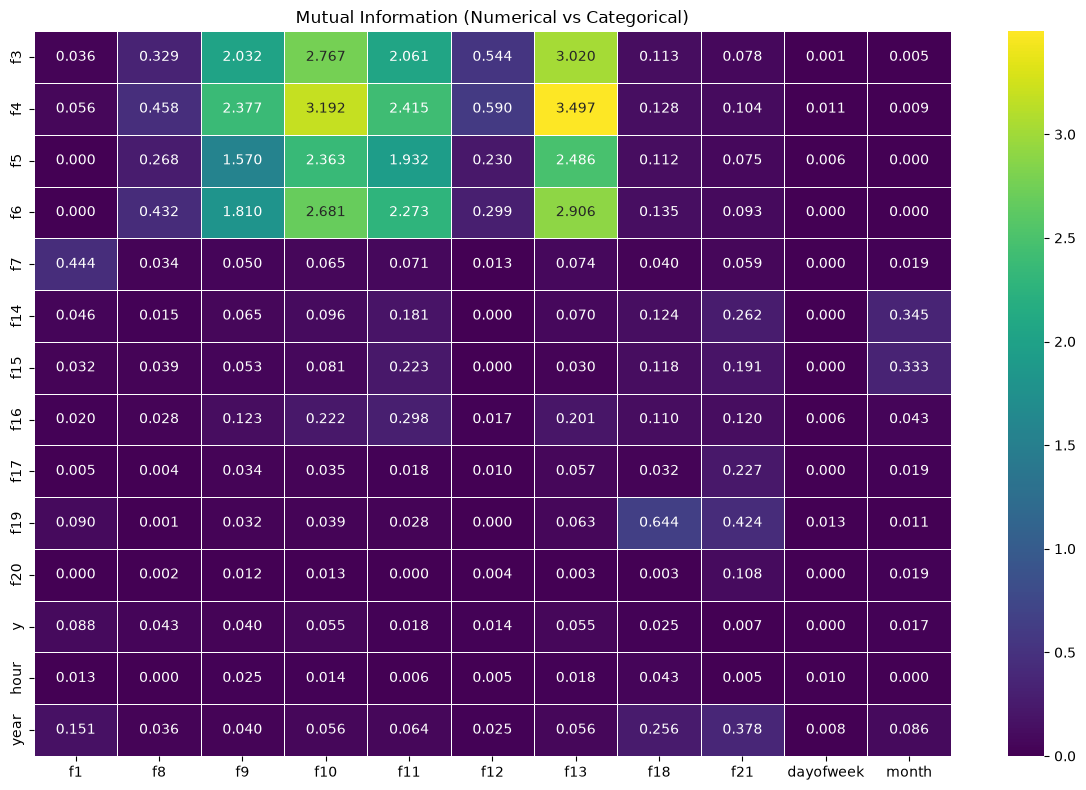

In [18]:
from sklearn.feature_selection import mutual_info_regression


def mi_score(num_col, cat_col):

    tmp = pd.DataFrame({
        "num": num_col,
        "cat": cat_col
    }).dropna()

    if len(tmp) < 2:
        return np.nan

    codes = pd.factorize(tmp["cat"])[0]

    try:
        return mutual_info_regression(
            tmp[["num"]],
            codes,
            discrete_features=False,
            random_state=42
        )[0]

    except:

        return np.nan


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)


num_cols = sample_df.select_dtypes(
    include=["number"]
).columns.tolist()

cat_cols = sample_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()


if "f2" in num_cols:
    num_cols.remove("f2")

if "f2" in cat_cols:
    cat_cols.remove("f2")


mi_matrix = pd.DataFrame(
    index=num_cols,
    columns=cat_cols
)


for n in num_cols:

    for c in cat_cols:

        mi_matrix.loc[n, c] = mi_score(
            sample_df[n],
            sample_df[c]
        )


mi_matrix = mi_matrix.astype(float)


plt.figure(figsize=(12, 8))

sns.heatmap(
    mi_matrix,
    annot=True,
    cmap="viridis",
    fmt=".3f",
    linewidths=.5
)

plt.title("Mutual Information (Numerical vs Categorical)")
plt.tight_layout()
plt.show()

Mutual Information Heatmap (Numerical vs Boolean)

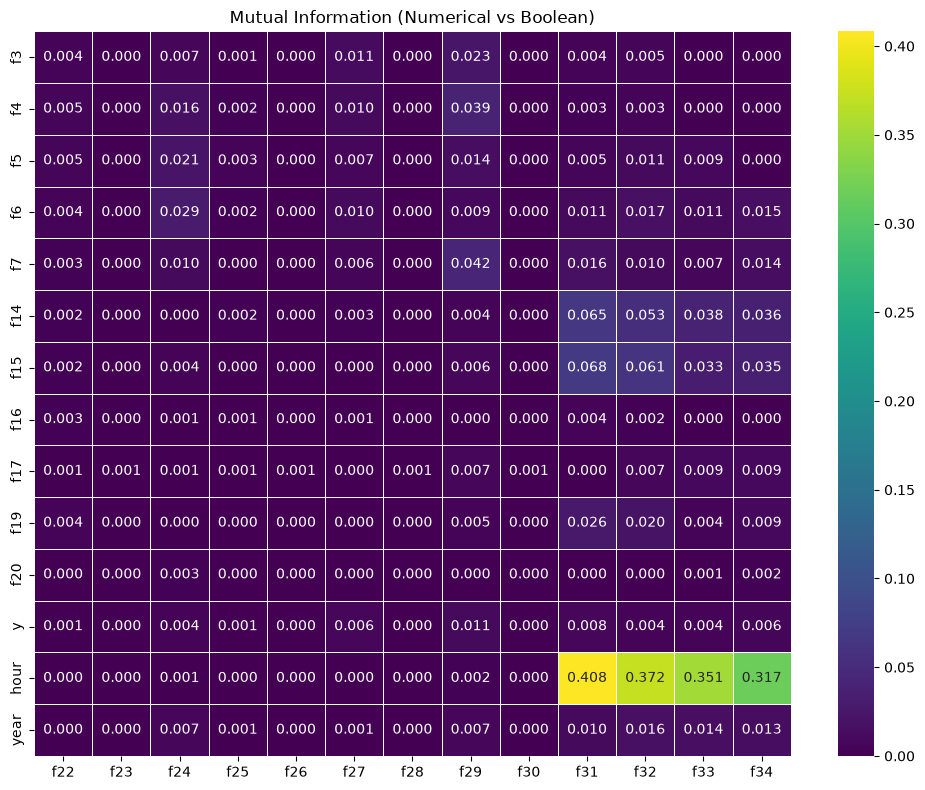

In [19]:
def mi_score(num_col, bool_col):

    tmp = pd.DataFrame({
        "num": num_col,
        "bool": bool_col
    }).dropna()

    if len(tmp) < 2:
        return np.nan

    try:
        return mutual_info_classif(
            tmp[["num"]],
            tmp["bool"].astype(int),
            discrete_features=False,
            random_state=42
        )[0]

    except:

        return np.nan


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)


num_cols = sample_df.select_dtypes(
    include=["number"]
).columns.tolist()

bool_cols = sample_df.select_dtypes(
    include=["bool"]
).columns.tolist()


if "f2" in num_cols:
    num_cols.remove("f2")

if "f2" in bool_cols:
    bool_cols.remove("f2")


mi_matrix = pd.DataFrame(
    index=num_cols,
    columns=bool_cols
)


for n in num_cols:

    for b in bool_cols:

        mi_matrix.loc[n, b] = mi_score(
            sample_df[n],
            sample_df[b]
        )


mi_matrix = mi_matrix.astype(float)


plt.figure(figsize=(10, 8))

sns.heatmap(
    mi_matrix,
    annot=True,
    cmap="viridis",
    fmt=".3f",
    linewidths=.5
)

plt.title("Mutual Information (Numerical vs Boolean)")
plt.tight_layout()
plt.show()

Cramer's V Heatmap (Boolean vs Categorical)

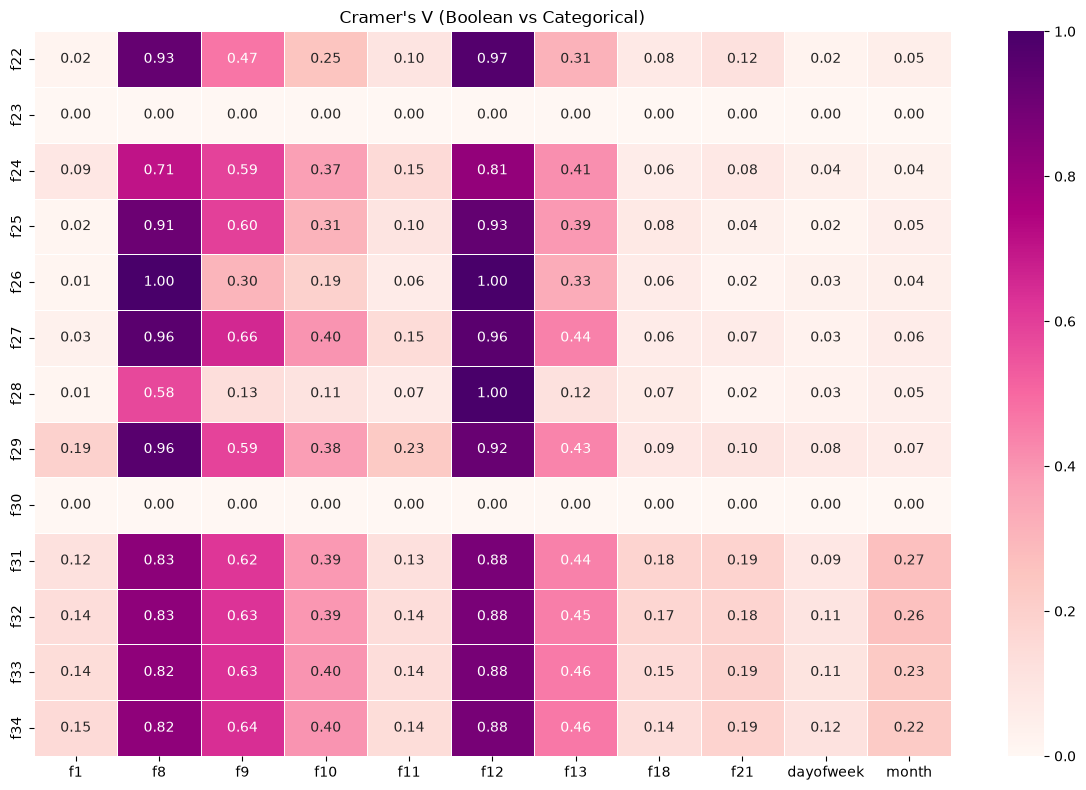

In [20]:
def cramers_v(x, y):

    tbl = pd.crosstab(x, y)

    if tbl.empty:
        return np.nan

    try:

        chi2 = chi2_contingency(tbl)[0]

        n = tbl.to_numpy().sum()

        r, k = tbl.shape

        if min(r - 1, k - 1) <= 0:
            return 0

        return np.sqrt(
            (chi2 / n) /
            min(r - 1, k - 1)
        )

    except:

        return np.nan


sample_df = df.sample(
    min(5000, len(df)),
    random_state=42
)


bool_cols = sample_df.select_dtypes(
    include=["bool"]
).columns.tolist()

cat_cols = sample_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()


bool_cols = [c for c in bool_cols if c != "f2"]
cat_cols = [c for c in cat_cols if c != "f2"]


mat = pd.DataFrame(
    index=bool_cols,
    columns=cat_cols
)


for b in bool_cols:

    for c in cat_cols:

        mat.loc[b, c] = cramers_v(
            sample_df[b],
            sample_df[c]
        )


mat = mat.astype(float)


plt.figure(figsize=(12, 8))

sns.heatmap(
    mat,
    annot=True,
    cmap="RdPu",
    vmin=0,
    vmax=1,
    fmt=".2f",
    linewidths=.5
)

plt.title("Cramer's V (Boolean vs Categorical)")
plt.tight_layout()
plt.show()